In [2]:
import cv2
import os
import torch
import torchvision
import numpy as np
import pandas as pd
import random
import xml.etree.ElementTree as ET
import torchvision.transforms as T
from PIL import Image
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection import MaskRCNN
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torch.utils.data import DataLoader, Dataset
from matplotlib import pyplot as plt
from matplotlib import patches
from tqdm import tqdm

In [3]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device="cpu"
print(f"Using device: {device}")

Using device: cpu


In [4]:
# from torchvision.datasets import VOCDetection
# #downLoad Pascal VOC dataset
# VOCDetection(root='VOC_data', year='2012', image_set='trainval', download=True)

In [5]:
# Define VOC_CLASSES for segmentation
VOC_CLASSES = {
    "bicycle": 2, "bus": 6, "car": 7, "motorbike": 14, "person": 15
}
# Re-index values
VOC_CLASSES_ReIndex = {name: idx+1 for idx, (name, _) in enumerate(VOC_CLASSES.items())}
print(VOC_CLASSES_ReIndex)

{'bicycle': 1, 'bus': 2, 'car': 3, 'motorbike': 4, 'person': 5}


In [6]:
class Config:
    root_dir = 'VOC2012'
    num_epochs = 20
    batch_size = 5
    learning_rate = 0.001
    momentum = 0.9
    weight_decay = 0.0005
    iou_threshold = 0.5
    patience = 5
    classes = VOC_CLASSES_ReIndex
    subset_size_class = 200

In [7]:
# make subset class balanced
def getSubsetClassesMask(root, classes, image_set,  subset_size_class):
    image_dir = os.path.join(root, "JPEGImages")
    annotation_dir = os.path.join(root, "Annotations")
    image_set_file_img = os.path.join(root, "ImageSets", "Main", f"{image_set}.txt")
    image_set_file_mask = os.path.join(root, "ImageSets", "Segmentation", f"{image_set}.txt")  # 
    
    # Read image mask ids
    with open(image_set_file_mask) as f:
        image_ids_mask = f.read().strip().split()

    tmp_ImgSet = []
    for imgSet in os.listdir(os.path.join(root, "ImageSets", "Main")):
        if imgSet.endswith(f"_{image_set}.txt"):
            subset_class = imgSet.split("_")[0]
            if str(subset_class) in VOC_CLASSES:
                subset_class_path = os.path.join(root, "ImageSets", "Main", f"{subset_class}_{image_set}.txt")
                with open(subset_class_path) as f:
                    image_ids_img = [line.strip().split(" ")[0] for line in f.readlines()]
                    image_ids_inter = [x for x in image_ids_img if x in image_ids_mask] # intersection of list
                    image_ids = random.sample(image_ids_inter, subset_size_class) # make subset
                tmp_ImgSet.extend(image_ids)

    tmp = []
    for image_id in tmp_ImgSet:   
        img_path = os.path.join(image_dir, f"{image_id}.jpg")
        annotation_path = os.path.join(annotation_dir, f"{image_id}.xml")
        
        tree = ET.parse(annotation_path)
        root_tree = tree.getroot()

        for obj in root_tree.iter('object'):
            class_name = obj.find('name').text
            if class_name in VOC_CLASSES:
                tmp.append(image_id)

    subset=set(tmp) #get unique file
    new_set_file = os.path.join(root, "ImageSets", "Main", f"{image_set}_subsetBalanced.txt")
    with open(new_set_file, "w") as file:
        for value in subset:
            file.write(f"{value}\n")

In [6]:
# get subset classes
getSubsetClassesMask(root=Config.root_dir, classes=VOC_CLASSES, image_set='train', subset_size_class=Config.subset_size_class)
getSubsetClassesMask(root=Config.root_dir, classes=VOC_CLASSES, image_set='val', subset_size_class=int(Config.subset_size_class * 0.3))


In [10]:
# Define the model
def get_model(num_classes):
    # Load a pre-trained Mask R-CNN model with a ResNet-50 backbone
    model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT,
                                 weights_backbone=ResNet50_Weights.DEFAULT, trainable_backbone_layers=0)
    
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the box predictor
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)  # FastRCNNPredictor
    
    # Get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256  # Mask R-CNN mask predictor hidden layer size (default is 256)
    # Replace the mask predictor with new number of classes
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    
    return model

In [11]:
# Load the Mask R-CNN model
model = get_model(len(Config.classes)+1)
model = model.to(device)

In [12]:
# fine tunned classes
model.roi_heads.box_predictor

FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=6, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=24, bias=True)
)

In [13]:
# fine tunned classes
model.roi_heads.mask_predictor

MaskRCNNPredictor(
  (conv5_mask): ConvTranspose2d(256, 256, kernel_size=(2, 2), stride=(2, 2))
  (relu): ReLU(inplace=True)
  (mask_fcn_logits): Conv2d(256, 6, kernel_size=(1, 1), stride=(1, 1))
)

In [11]:
trainable_params = [name for name, param in model.named_parameters() if param.requires_grad]
print(trainable_params)

['backbone.fpn.inner_blocks.0.0.weight', 'backbone.fpn.inner_blocks.0.0.bias', 'backbone.fpn.inner_blocks.1.0.weight', 'backbone.fpn.inner_blocks.1.0.bias', 'backbone.fpn.inner_blocks.2.0.weight', 'backbone.fpn.inner_blocks.2.0.bias', 'backbone.fpn.inner_blocks.3.0.weight', 'backbone.fpn.inner_blocks.3.0.bias', 'backbone.fpn.layer_blocks.0.0.weight', 'backbone.fpn.layer_blocks.0.0.bias', 'backbone.fpn.layer_blocks.1.0.weight', 'backbone.fpn.layer_blocks.1.0.bias', 'backbone.fpn.layer_blocks.2.0.weight', 'backbone.fpn.layer_blocks.2.0.bias', 'backbone.fpn.layer_blocks.3.0.weight', 'backbone.fpn.layer_blocks.3.0.bias', 'rpn.head.conv.0.0.weight', 'rpn.head.conv.0.0.bias', 'rpn.head.cls_logits.weight', 'rpn.head.cls_logits.bias', 'rpn.head.bbox_pred.weight', 'rpn.head.bbox_pred.bias', 'roi_heads.box_head.fc6.weight', 'roi_heads.box_head.fc6.bias', 'roi_heads.box_head.fc7.weight', 'roi_heads.box_head.fc7.bias', 'roi_heads.box_predictor.cls_score.weight', 'roi_heads.box_predictor.cls_score.

In [12]:
trainable_params_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params_count)

20489011


In [13]:
params = [param for name, param in model.named_parameters() if param.requires_grad]
len(params )

42

In [14]:
# transform original
model.transform

GeneralizedRCNNTransform(
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    Resize(min_size=(800,), max_size=1333, mode='bilinear')
)

In [15]:
class ResizeNormalizeTransform:
    #min_size=800, max_size=1333
    def __init__(self, min_size=400, max_size=600, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
        self.min_size = min_size
        self.max_size = max_size
        self.mean = mean
        self.std = std
    
    def __call__(self, image, boxes, masks=None):
        # Get original size
        original_width, original_height = image.size
        
        # Calculate scaling factor to maintain aspect ratio
        min_original_size = float(min(original_width, original_height))
        max_original_size = float(max(original_width, original_height))
        
        # Calculate scale factor
        scale = self.min_size / min_original_size
        
        # Check if the scaling would make the longer side too big
        if scale * max_original_size > self.max_size:
            scale = self.max_size / max_original_size
        
        # Calculate new size
        new_width = int(original_width * scale)
        new_height = int(original_height * scale)
        
        # Resize image
        image = T.Resize((new_height, new_width))(image)
        
        # Adjust bounding boxes
        if boxes is not None and len(boxes):
            boxes = boxes.clone()
            boxes[:, [0, 2]] *= (new_width / original_width)  # Scale x coordinates
            boxes[:, [1, 3]] *= (new_height / original_height)  # Scale y coordinates
        
        # Adjust masks if provided
        if masks is not None and len(masks):
            masks = torch.nn.functional.interpolate(
                masks.unsqueeze(1).float(),
                size=(new_height, new_width),
                mode="nearest"
            ).squeeze(1)
        
        # Convert to tensor and normalize
        image = T.ToTensor()(image)
        image = T.Normalize(mean=self.mean, std=self.std)(image)
        
        return image, boxes, masks

# Instance transformation
transform = ResizeNormalizeTransform()

In [16]:
class VOCDataset(Dataset):
    def __init__(self, root, classes, image_set='train', transform=None):
        super().__init__()
        
        self.root = root
        self.classes = classes
        self.image_set = image_set
        self.transform = transform

        # Paths
        self.image_dir = os.path.join(root, "JPEGImages")
        self.annotation_dir = os.path.join(root, "Annotations")
        self.mask_dir = os.path.join(root, "SegmentationObject")
        # Load image ids
        self.image_set_file = os.path.join(root, "ImageSets", "Main", f"{image_set}_subsetBalanced.txt")
        
        with open(self.image_set_file) as f:
            self.image_ids = f.read().strip().split()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        
        # Load image
        img_path = os.path.join(self.image_dir, f"{image_id}.jpg")
        image = Image.open(img_path).convert("RGB")
        
        # Load annotation and masks
        annot_path = os.path.join(self.annotation_dir, f"{image_id}.xml")
        mask_path = os.path.join(self.mask_dir, f"{image_id}.png")        
        
        boxes, labels, masks = self._parse_voc_annotation(
            annot_path,
            mask_path,
            image.size[1], 
            image.size[0]
        )
        
        # Apply transformations
        if self.transform:
            image, boxes, masks = self.transform(image, boxes, masks)
        
        target = {
            'boxes': boxes,
            'labels': labels,
            'masks': masks,
            'image_id': torch.tensor([idx])
        }
        
        return image, target, image_id 

    def _parse_voc_annotation(self, xml_path, mask_path, height, width):
        # Parse XML annotation
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        boxes, labels, object_ids, masks = [], [], [], []
        
        # Load instance segmentation mask
        if os.path.exists(mask_path):
            mask_array = np.array(Image.open(mask_path))
        else:
            mask_array = np.zeros((height, width), dtype=np.uint8)
    
        # Parse objects
        for obj_id, obj in enumerate(root.findall("object")):
            name = obj.find("name").text
            if name in self.classes:
                # Add label and box
                labels.append(self.classes[name])
                object_ids.append(obj_id + 1)  # VOC uses 1-based indexing
                
                bbox = obj.find("bndbox")
                box = [
                    float(bbox.find(coord).text) 
                    for coord in ["xmin", "ymin", "xmax", "ymax"]
                ]
                boxes.append(box)
                
                # Create binary mask for this instance
                instance_mask = (mask_array == obj_id + 1).astype(np.uint8)
                masks.append(instance_mask)
    
        # Convert to tensors
        if not boxes:
            return (
                torch.zeros((0, 4), dtype=torch.float32),
                torch.zeros((0,), dtype=torch.int64),
                torch.zeros((0, height, width), dtype=torch.uint8)
            )
        
        return (
            torch.tensor(boxes, dtype=torch.float32),
            torch.tensor(labels, dtype=torch.int64),
            torch.stack([torch.from_numpy(m) for m in masks]) if masks else torch.zeros((0, height, width), dtype=torch.uint8)
        )

In [17]:
# Instantiate datasets
train_dataset = VOCDataset(root=Config.root_dir, classes = Config.classes, image_set='train', transform=transform)
val_dataset = VOCDataset(root=Config.root_dir, classes = Config.classes, image_set='val', transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=Config.batch_size, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=Config.batch_size, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

print("Number of training samples:", len(train_dataset))
print("Number of validation samples:", len(val_dataset))


Number of training samples: 277
Number of validation samples: 110


In [18]:
# VOC_CLASSES_inverted
VOC_CLASSES_inverted = {v: k for k, v in VOC_CLASSES_ReIndex.items()}
print(VOC_CLASSES_inverted)

{1: 'bicycle', 2: 'bus', 3: 'car', 4: 'motorbike', 5: 'person'}


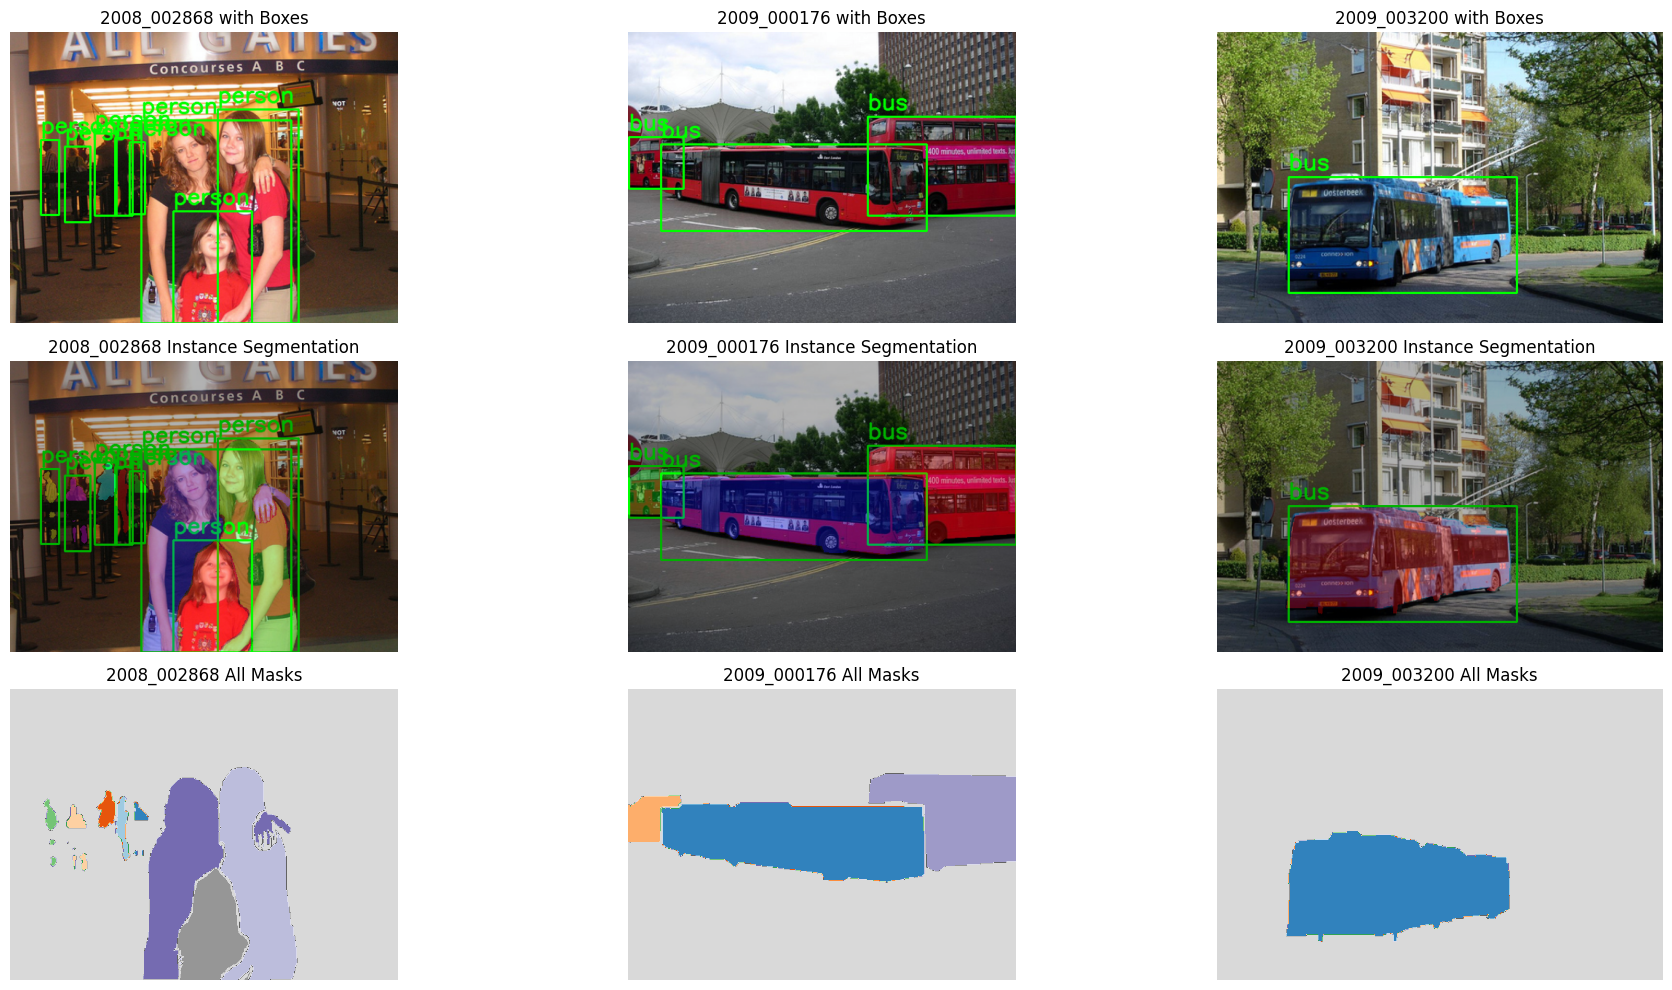

In [19]:
# visualize a batch of train data loader
images, target, filenames = next(iter(train_loader))
fig = plt.figure(figsize=(20, 10))
rows, cols = 3, 3

for i in range(cols):
    # Plot original image with boxes
    ax = fig.add_subplot(rows, cols, i+1)
    img = np.transpose(images[i], (1, 2, 0))
    img = img.detach().cpu().numpy()
    img = ((img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]) * 255).astype(np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR) 
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

    boxes = target[i]['boxes']
    labels = target[i]['labels']
    masks = target[i]['masks']
    filename = filenames[i]

    # Draw boxes and labels
    for j in range(len(boxes)):
        x1, y1, x2, y2 = map(int, boxes[j])
        cv2.rectangle(img, (x1, y1), (x2, y2), color=(0, 255, 0), thickness=2)
        
        class_id = int(labels[j])
        label_name = VOC_CLASSES_inverted.get(class_id, "Unknown")
        text_position = (x1, y1 - 10 if y1 > 20 else y1 + 10)
        
        cv2.putText(
            img, 
            label_name, 
            text_position, 
            cv2.FONT_HERSHEY_SIMPLEX, 
            1.0,
            (0, 255, 0),
            thickness=2,
            lineType=cv2.LINE_AA
        )
    
    ax.imshow(img)
    ax.set_title(f'{filename} with Boxes')
    ax.axis('off')
    
    # Plot individual masks
    ax = fig.add_subplot(rows, cols, i+cols+1)
    
    # Create a colored mask visualization
    mask_overlay = np.zeros_like(img)
    colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0), (255,0,255), (0,255,255)]
    
    if len(masks) > 0:
        for j, mask in enumerate(masks):
            color = np.array(colors[j % len(colors)])
            mask_np = mask.numpy()[..., None]  # Add channel dimension
            mask_overlay += (mask_np * color.reshape(1, 1, 3)).astype(np.uint8)
    
    # Blend with original image
    final_img = cv2.addWeighted(img, 0.7, mask_overlay, 0.3, 0)
    ax.imshow(final_img)
    ax.set_title(f'{filename} Instance Segmentation')
    ax.axis('off')
    
    # Plot all masks separately
    ax = fig.add_subplot(rows, cols, i+2*cols+1)
    if len(masks) > 0:
        all_masks = np.zeros(masks[0].shape, dtype=np.float32)
        for j, mask in enumerate(masks):
            mask_np = mask.numpy()
            # Add each mask with a different value
            all_masks = np.maximum(all_masks, (j + 1) * mask_np)
        
        ax.imshow(all_masks, cmap='tab20c_r')
    else:
        ax.imshow(np.zeros((masks.shape[1], masks.shape[2])), cmap='tab20')
    
    ax.set_title(f'{filename} All Masks')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [20]:
# check
def check_model_output(model, val_loader, device):
    model.eval()
    
    # Get one batch of data
    images, targets, _ = next(iter(val_loader))
    images = list(image.to(device) for image in images)
    
    # Get model predictions
    with torch.no_grad():
        outputs = model(images)
    
    # Print detailed information about the output
    print("Type of model output:", type(outputs))  # Should be list
    print("\nLength of outputs (batch size):", len(outputs))
    
    # Look at first prediction in batch
    first_pred = outputs[0]
    print("\nFirst prediction contains:")
    print("Keys:", first_pred.keys())  # Should show 'boxes', 'labels', 'scores'
    
    print("\nDetailed structure:")
    print("Boxes shape:", first_pred['boxes'].shape)  # [N, 4] where N is number of detections
    print("Labels shape:", first_pred['labels'].shape)  # [N]
    print("Scores shape:", first_pred['scores'].shape)  # [N]
    print("Masks shape:", first_pred['masks'].shape)  # [N]
    
    # Print sample values
    print("\nSample values for first detection:")
    if len(first_pred['boxes']) > 0:
        print("Box coordinates (x1,y1,x2,y2):", first_pred['boxes'][0].tolist())
        print("Label:", first_pred['labels'][0].item())
        print("Confidence score:", first_pred['scores'][0].item())
    
    return outputs

# usage:
pred_output = check_model_output(model, val_loader, device)

Type of model output: <class 'list'>

Length of outputs (batch size): 5

First prediction contains:
Keys: dict_keys(['boxes', 'labels', 'scores', 'masks'])

Detailed structure:
Boxes shape: torch.Size([100, 4])
Labels shape: torch.Size([100])
Scores shape: torch.Size([100])
Masks shape: torch.Size([100, 1, 399, 598])

Sample values for first detection:
Box coordinates (x1,y1,x2,y2): [249.76983642578125, 242.4665069580078, 301.3515930175781, 342.24951171875]
Label: 4
Confidence score: 0.406034916639328


In [21]:
# Check
def check_target_format(val_loader):
    # Get one batch
    images, targets, _ = next(iter(val_loader))
    
    print("Target format:")
    print("Type of targets:", type(targets))
    print("Number of targets:", len(targets))
    
    # Look at first target
    first_target = targets[0]
    print("\nFirst target contains:")
    print("Keys:", first_target.keys())
    
    # Print shapes
    for key, value in first_target.items():
        print(f"{key} shape:", value.shape)
        print(f"Sample {key}:", value[0] if len(value) > 0 else "empty")

# Usage:
check_target_format(val_loader)

Target format:
Type of targets: <class 'tuple'>
Number of targets: 5

First target contains:
Keys: dict_keys(['boxes', 'labels', 'masks', 'image_id'])
boxes shape: torch.Size([1, 4])
Sample boxes: tensor([199.7320, 181.5808, 314.5480, 399.0000])
labels shape: torch.Size([1])
Sample labels: tensor(5)
masks shape: torch.Size([1, 399, 598])
Sample masks: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
image_id shape: torch.Size([1])
Sample image_id: tensor(0)


## Metrics

In [26]:
# """Calculate mean Average Precision"""
def calculate_map(predictions, targets, iou_threshold=0.5):
    """Calculate mean Average Precision"""
    # Initialize variables for mAP calculation
    aps = []
    unique_labels = set()
    
    # Get all unique class labels
    for target in targets:
        unique_labels.update(target['labels'].cpu().numpy())
    
    # Calculate AP for each class
    for class_id in unique_labels:
        true_positives = []
        scores = []
        num_gt = 0
        
        # Go through all images
        for pred, target in zip(predictions, targets):
            pred_boxes = pred['boxes']
            pred_scores = pred['scores']
            pred_labels = pred['labels']
            
            target_boxes = target['boxes']
            target_labels = target['labels']
            
            # Count ground truths for this class
            num_gt += (target_labels == class_id).sum().item()
            
            # Get predictions for this class
            class_mask = pred_labels == class_id
            class_boxes = pred_boxes[class_mask]
            class_scores = pred_scores[class_mask]
            
            # Get ground truth boxes for this class
            gt_mask = target_labels == class_id
            gt_boxes = target_boxes[gt_mask]
            
            if len(class_boxes) > 0 and len(gt_boxes) > 0:
                # Calculate IoU between predictions and ground truth
                ious = box_iou(class_boxes, gt_boxes)
                
                # For each prediction, check if it matches ground truth
                for i in range(len(class_boxes)):
                    scores.append(class_scores[i].item())
                    if ious[i].max() >= iou_threshold:
                        true_positives.append(1)
                    else:
                        true_positives.append(0)
        
        if len(scores) > 0:
            # Sort by score
            scores = torch.tensor(scores)
            true_positives = torch.tensor(true_positives)
            sorted_indices = torch.argsort(scores, descending=True)
            true_positives = true_positives[sorted_indices]
            
            # Calculate precision and recall points
            cumsum = torch.cumsum(true_positives, dim=0)
            precision = cumsum / torch.arange(1, len(cumsum) + 1)
            recall = cumsum / num_gt if num_gt > 0 else cumsum * 0
            
            # Calculate AP using 11-point interpolation
            ap = 0
            for t in torch.linspace(0, 1, 11):
                if torch.sum(recall >= t) == 0:
                    p = 0
                else:
                    p = torch.max(precision[recall >= t])
                ap += p / 11
            aps.append(ap.item())
    
    return sum(aps) / len(aps) if aps else 0


In [27]:
# """Calculate overall precision and recall"""
def calculate_precision_recall(predictions, targets, iou_threshold=0.5, score_threshold=0.5):
    """Calculate overall precision and recall"""
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    
    for pred, target in zip(predictions, targets):
        pred_boxes = pred['boxes']
        pred_scores = pred['scores']
        target_boxes = target['boxes']
        
        # Filter predictions by score threshold
        mask = pred_scores >= score_threshold
        pred_boxes = pred_boxes[mask]
        
        if len(pred_boxes) > 0 and len(target_boxes) > 0:
            # Calculate IoU between predictions and ground truth
            ious = box_iou(pred_boxes, target_boxes)
            
            # Count matches
            pred_matches = ious.max(dim=1)[0] >= iou_threshold
            target_matches = ious.max(dim=0)[0] >= iou_threshold
            
            true_positives += pred_matches.sum().item()
            false_positives += (~pred_matches).sum().item()
            false_negatives += (~target_matches).sum().item()
        else:
            false_positives += len(pred_boxes)
            false_negatives += len(target_boxes)
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    
    return precision, recall


In [24]:
# """Calculate IoU between two sets of boxes"""
def box_iou(boxes1, boxes2):
    """Calculate IoU between two sets of boxes"""
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    
    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    
    union = area1[:, None] + area2 - inter
    
    iou = inter / (union + 1e-6)
    return iou
    

In [25]:
def calculate_batch_iou(predictions, targets):
    """Calculate IoU for a batch of predictions"""
    total_iou = 0
    count = 0
    
    for pred, target in zip(predictions, targets):
        pred_boxes = pred['boxes']
        target_boxes = target['boxes']
        
        if len(pred_boxes) > 0 and len(target_boxes) > 0:
            # Calculate IoU between predicted and target boxes
            ious = box_iou(pred_boxes, target_boxes)
            # Take the maximum IoU for each predicted box
            total_iou += ious.max(dim=1)[0].mean().item()
            count += 1
    
    return total_iou / count if count > 0 else 0

## Train Process

In [22]:
def train_one_epoch(model, optimizer, train_loader, device):
    
    model.train()
    total_loss = 0

    with tqdm(train_loader, unit="batch", leave=False, bar_format='{desc:<5.5}{percentage:3.0f}%|{bar:50}{r_bar}') as tepoch:
        for batch_idx, (images, targets, _) in enumerate(tepoch):
            # Move data to device
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Clear gradients
            optimizer.zero_grad()
            
            # Forward pass
            loss_dict = model(images, targets)

            # Calculate total loss
            losses = sum(loss for loss in loss_dict.values())

            # Backward pass
            losses.backward()

            # Add gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Update weights
            optimizer.step()

            # Update total loss
            total_loss += losses.item()

            tepoch.set_postfix(loss=losses.item())
    
    return total_loss / len(train_loader)
    

In [23]:
def evaluate(model, val_loader, device):

    model.eval()
    metrics = {
        'mAP': 0,
        'precision': 0,
        'recall': 0,
        'bbox_iou': 0
    }
    
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for images, targets, _ in tqdm(val_loader, leave=False, bar_format='{desc:<5.5}{percentage:3.0f}%|{bar:50}{r_bar}'):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Get predictions
            outputs = model(images)
            
            # Store predictions and targets for metric calculation
            all_predictions.extend(outputs)
            all_targets.extend(targets)
            
            # Calculate batch IoU
            batch_iou = calculate_batch_iou(outputs, targets)
            metrics['bbox_iou'] += batch_iou
    
    # Calculate average IoU
    metrics['bbox_iou'] /= len(val_loader)
    
    # Calculate mAP
    metrics['mAP'] = calculate_map(all_predictions, all_targets)
    
    # Calculate precision and recall
    precision, recall = calculate_precision_recall(all_predictions, all_targets)
    metrics['precision'] = precision
    metrics['recall'] = recall
    
    return metrics


In [28]:
def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs, device, save_path='checkpoints'):

    best_map = 0.0  # Track best mAP
    os.makedirs(save_path, exist_ok=True)

    # Initialize dictionary to store metrics
    history = {
        'train_loss': [],
        'val_map': [],
        'val_precision': [],
        'val_recall': [],
        'val_iou': []
    }
    
    for epoch in range(num_epochs):
        
        # Training phase       
        train_loss = train_one_epoch(model, optimizer, train_loader, device)
        
        # Validation phase
        metrics = evaluate(model, val_loader, device)
        current_map = metrics['mAP']

        # scheduling step
        scheduler.step(metrics['mAP'])

        # Store metrics in history
        history['train_loss'].append(train_loss)
        history['val_map'].append(metrics['mAP'])
        history['val_precision'].append(metrics['precision'])
        history['val_recall'].append(metrics['recall'])
        history['val_iou'].append(metrics['bbox_iou'])
        
        # Print epoch results
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"Training Loss: {train_loss:.4f}")
        print(f"Validation mAP: {metrics['mAP']:.4f}")
        print(f"Validation Precision: {metrics['precision']:.4f}")
        print(f"Validation Recall: {metrics['recall']:.4f}")
        print(f"Validation IoU: {metrics['bbox_iou']:.4f}")
        
        # Save best model
        if current_map > best_map:
            best_map = current_map
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_map': best_map,
                'metrics': metrics,
                'history': history
            }
            torch.save(checkpoint, f"{save_path}/best_model_maskRCNN.pth")
            print(f"New best model saved with mAP: {best_map:.4f}")
        
        # Save checkpoint every N epochs (e.g., every 5 epochs)
        if (epoch + 1) % 5 == 0:
            checkpoint = {
               'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_map': best_map,
                'metrics': metrics,
                'history': history
            }
            torch.save(checkpoint, f"{save_path}/model_epoch_{epoch+1}_maskRCNN.pth")
    
    return model, best_map, history


In [30]:
def plot_training_history(history):
    """
    Plot training and validation metrics
    """
    plt.figure(figsize=(18, 8))
    
    # Plot training loss
    plt.subplot(2, 2, 1)
    plt.plot(history['train_loss'], label='Training Loss')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot mAP
    plt.subplot(2, 2, 2)
    plt.plot(history['val_map'], label='Validation mAP')
    plt.title('Validation mAP over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('mAP')
    plt.legend()
    plt.grid(True)
    
    # Plot Precision/Recall
    plt.subplot(2, 2, 3)
    plt.plot(history['val_precision'], label='Precision')
    plt.plot(history['val_recall'], label='Recall')
    plt.title('Precision and Recall over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    
    # Plot IoU
    plt.subplot(2, 2, 4)
    plt.plot(history['val_iou'], label='Validation IoU')
    plt.title('Validation IoU over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history_MaskRCNN.png')
    plt.show()
    plt.close()


### Train the model

In [31]:
# Learning Rate Warmup
def get_lr_scheduler(optimizer, num_epochs):
    """Create learning rate scheduler with warmup"""
    def lr_lambda(epoch):
        if epoch < 3:  # Warmup for first 3 epochs
            return (epoch + 1) / 3
        return 1.0 if epoch < num_epochs * 0.6 else 0.1
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


In [ ]:
# Prepare optimizer and scheduler
params = [param for name, param in model.named_parameters() if param.requires_grad]
optimizer = torch.optim.SGD(params, lr=Config.learning_rate, momentum=Config.momentum, weight_decay=Config.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
#scheduler = get_lr_scheduler(optimizer, Config.num_epochs)



Epoch 1/20
Training Loss: 2.1676
Validation mAP: 0.1353
Validation Precision: 0.0000
Validation Recall: 0.0000
Validation IoU: 0.2381
New best model saved with mAP: 0.1353



Epoch 2/20
Training Loss: 1.0794
Validation mAP: 0.1950
Validation Precision: 0.0000
Validation Recall: 0.0000
Validation IoU: 0.2362
New best model saved with mAP: 0.1950



Epoch 3/20
Training Loss: 0.9860
Validation mAP: 0.2367
Validation Precision: 0.0000
Validation Recall: 0.0000
Validation IoU: 0.2218
New best model saved with mAP: 0.2367



Epoch 4/20
Training Loss: 0.9421
Validation mAP: 0.2822
Validation Precision: 0.0000
Validation Recall: 0.0000
Validation IoU: 0.2473
New best model saved with mAP: 0.2822



Epoch 5/20
Training Loss: 0.9104
Validation mAP: 0.2942
Validation Precision: 0.0000
Validation Recall: 0.0000
Validation IoU: 0.2647
New best model saved with mAP: 0.2942


...


Epoch 16/20
Training Loss: 0.8132
Validation mAP: 0.5026
Validation Precision: 0.6094
Validation Recall: 0.1660
Validation IoU: 0.2575



Epoch 17/20
Training Loss: 0.8018
Validation mAP: 0.5030
Validation Precision: 0.5616
Validation Recall: 0.1737
Validation IoU: 0.2607



Epoch 18/20
Training Loss: 0.7945
Validation mAP: 0.5360
Validation Precision: 0.5130
Validation Recall: 0.2458
Validation IoU: 0.2424
New best model saved with mAP: 0.5360



Epoch 19/20
Training Loss: 0.7955
Validation mAP: 0.5290
Validation Precision: 0.5652
Validation Recall: 0.2176
Validation IoU: 0.2761



Epoch 20/20
Training Loss: 0.7958
Validation mAP: 0.5578
Validation Precision: 0.5700
Validation Recall: 0.2375
Validation IoU: 0.2605
New best model saved with mAP: 0.5578


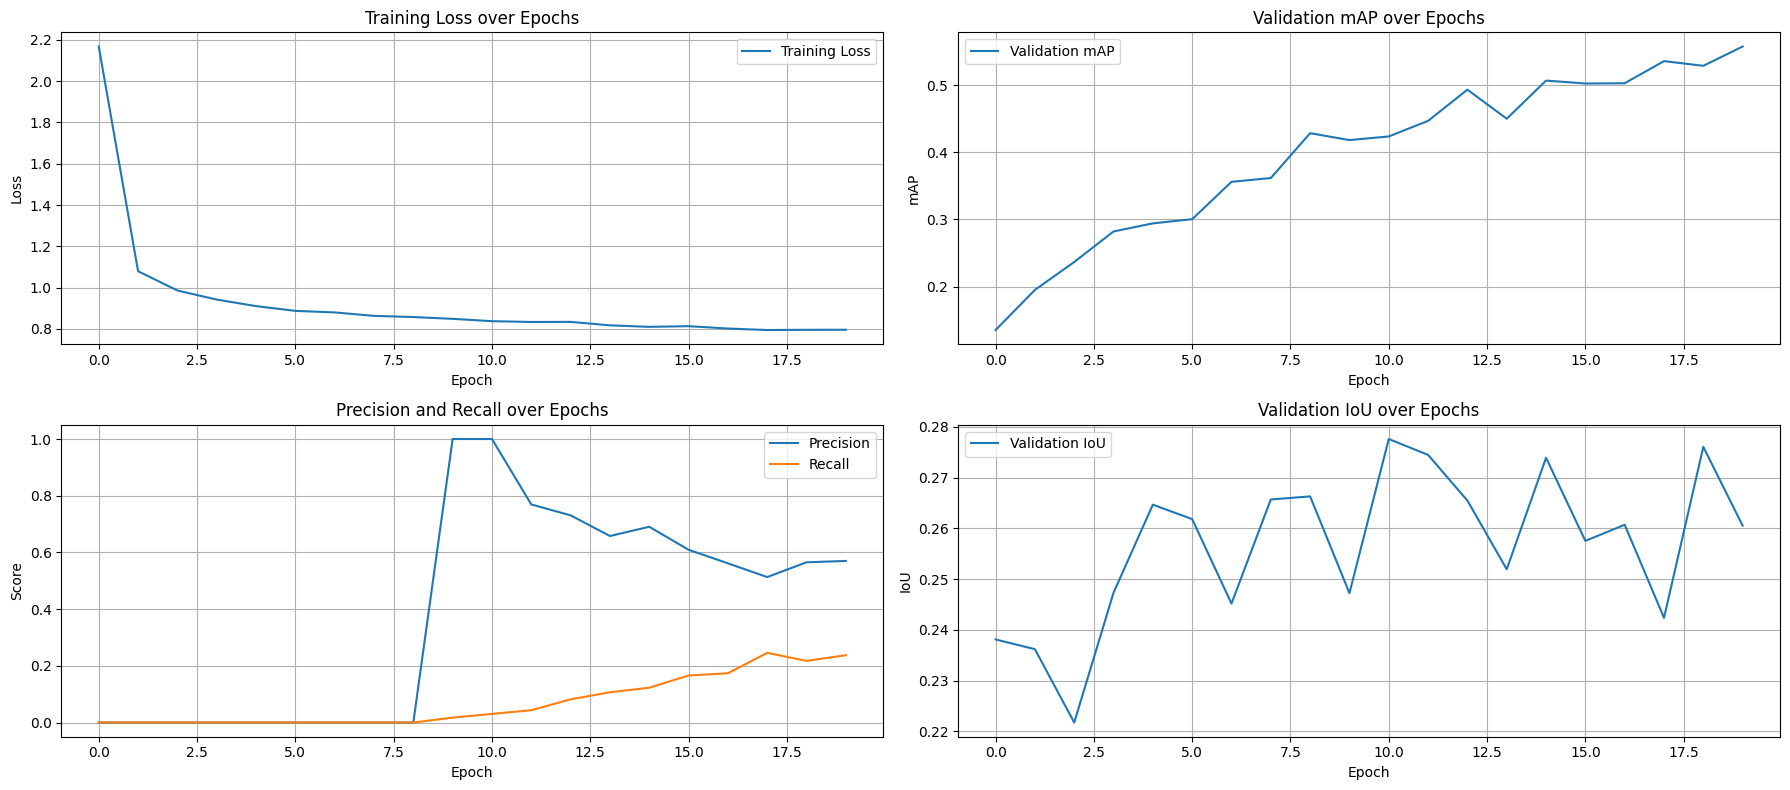

Best mAP: 0.5578 at epoch 20
Corresponding Precision: 0.5700
Corresponding Recall: 0.2375


In [32]:
# Train the model
model, best_map, history = train_model(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    scheduler, 
    Config.num_epochs, 
    device
)

In [ ]:
# Plot training history
plot_training_history(history)

# Get best mAP value
best_map = max(history['val_map'])
best_epoch = history['val_map'].index(best_map)

print(f"Best mAP: {best_map:.4f} at epoch {best_epoch + 1}")
print(f"Corresponding Precision: {history['val_precision'][best_epoch]:.4f}")
print(f"Corresponding Recall: {history['val_recall'][best_epoch]:.4f}")

In [29]:
def load_best_model(model, optimizer, load_path):
    """
    Load the best saved model
    """
    if os.path.exists(load_path):
        checkpoint = torch.load(load_path, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        best_map = checkpoint['best_map']
        epoch = checkpoint['epoch']
        history = checkpoint['history']
        print(f"Loaded best model with mAP: {best_map:.4f} from epoch {checkpoint['epoch']+1}")
        return model, optimizer, best_map, epoch, history
    else:
        print("No saved model found.")
        return model, optimizer, 0.0, -1, None

In [65]:
# prediction function
def predict_image(model, img_path, device, confidence_threshold=0.5):
    
    model.eval()
    
    image = Image.open(img_path).convert("RGB")

    image, _, _ = transform(image, None, None)

    # Prepare image for model
    image = image.to(device)
        
    with torch.no_grad():
        predictions = model([image])
    
    boxes = predictions[0]['boxes'].cpu()
    labels = predictions[0]['labels'].cpu()
    scores = predictions[0]['scores'].cpu()
    masks = predictions[0]['masks'].cpu()
    
    # Filter by confidence
    mask = scores >= confidence_threshold
    boxes = boxes[mask]
    labels = labels[mask]
    scores = scores[mask]
    masks = masks[mask]
    
    return image, boxes, labels, scores, masks

In [66]:
def visualize_predictions_with_masks(image, boxes, labels, scores, masks, VOC_CLASSES):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # Original image with boxes
    img = np.transpose(image, (1, 2, 0))
    img = img.detach().cpu().numpy()
    img = ((img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]) * 255).astype(np.uint8)
    
    # Show original image with boxes
    ax1.imshow(img)
    
    # Create colored mask overlay
    mask_overlay = np.zeros_like(img)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(masks)))[:, :3]
    
    for box, label, score, mask, color in zip(boxes, labels, scores, masks, colors):
        mask = mask.squeeze().numpy()
        mask_overlay[mask > 0.5] = color * 255
        
        # Draw box
        box = box.numpy().astype(int)
        rect = patches.Rectangle(
            (box[0], box[1]), box[2]-box[0], box[3]-box[1],
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax1.add_patch(rect)
        
        # Add label
        class_name = VOC_CLASSES_inverted.get(label.item(), "Unknown")
        ax1.text(box[0], box[1]-5, f'{class_name}: {score:.2f}',
                color='white', bbox=dict(facecolor=color))
    
    # Show mask overlay
    ax2.imshow(img)
    ax2.imshow(mask_overlay, alpha=0.5)
    
    ax1.set_title('Detections')
    ax2.set_title('Instance Segmentation')
    plt.show()

In [67]:
file = 'VOC2012/JPEGImages/2007_005988.jpg'
image, boxes, labels, scores, masks = predict_image(model, file, device)

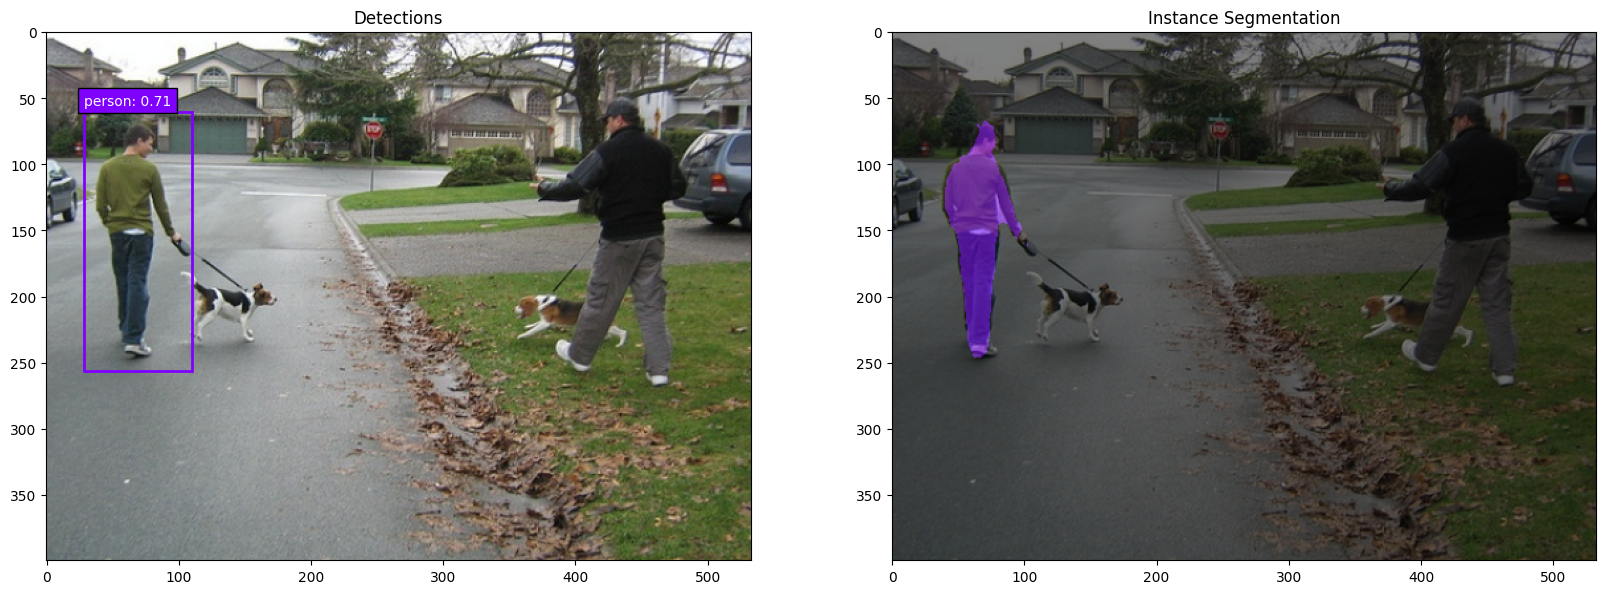

In [68]:
visualize_predictions_with_masks(image, boxes, labels, scores, masks, VOC_CLASSES_ReIndex)